# Random Forest Model

used the same random seed as the `categorical_model.ipynb` model to ensure faireness. I

Since random Forest does not require normally distributed or standardized numeric features. Missing numeric values are median-imputed and missing categorical values are imputed with the most frequent category inside the pipeline, so preprocessing is learned from training data only.

## Random Forest Workflow

- Feature engineering
- Split the data
- Train the model
- 5-fold cross validation
- Hyperparameter tuning
- Assess model performance

from: https://www.datacamp.com/tutorial/random-forests-classifier-python 

In [78]:
# Data Processing
import pandas as pd
import numpy as np

# Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

## 1. Load and audit the data

In [79]:
RANDOM_STATE = 42
DATA_PATH = 'train_test_network.csv'

df = pd.read_csv(DATA_PATH)
display(df.head())

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


In [80]:
label_counts = df["label"].value_counts(dropna=False).sort_index()
display(label_counts.rename("count").to_frame())

,count
label,
0,50000
1,161043


In [81]:
dash_percent = ((df.astype(str) == "-").mean() * 100).sort_values(ascending=False)
mostly_dash_cols = dash_percent[dash_percent > 95].index.tolist()

display(dash_percent[dash_percent > 0].rename("dash_percent").to_frame())

,dash_percent
ssl_issuer,99.994788
ssl_subject,99.994788
http_orig_mime_types,99.992419
weird_addl,99.925608
http_resp_mime_types,99.903337
http_user_agent,99.864009
http_uri,99.864009
http_method,99.864009
http_version,99.858797
http_trans_depth,99.856427


## 2. Prepare features

`type` is removed because it encodes the attack category and would leak information about the binary `label`. high-cardinality identifiers are removed because they can cause memorization and create a very large one-hot feature matrix.

In [82]:
def check_duplicates(X, y, target="label"):
    data = X.copy()
    data[target] = y.to_numpy()
    feature_cols = list(X.columns)

    label_variation = data.groupby(
        feature_cols,
        dropna=False,
    )[target].transform("nunique")

    conflicting_group_count = (
        data.groupby(feature_cols, dropna=False)[target]
        .nunique()
        .gt(1)
        .sum()
    )
    duplicate_count = X.duplicated().sum()
    ambiguous_row_count = (label_variation > 1).sum()

    print(f"Rows before cleaning: {len(data):,}")
    print(f"Duplicate feature rows: {duplicate_count:,}")
    print(f"Duplicate percentage: {X.duplicated().mean() * 100:.2f}%")
    print(f"Conflicting feature groups: {conflicting_group_count:,}")
    print(f"Rows in conflicting groups: {ambiguous_row_count:,}")

In [83]:
df_clean = df.drop(columns=mostly_dash_cols).copy()

target = "label"
X = df_clean.drop(columns=["label", "type"])
y = df_clean[target]

In [84]:
check_duplicates(X, y)

Rows before cleaning: 211,043
Duplicate feature rows: 20,588
Duplicate percentage: 9.76%
Conflicting feature groups: 0
Rows in conflicting groups: 0


In [85]:
def clean_duplicates(X, y, target="label"):
    data = X.copy()
    data[target] = y.to_numpy()
    feature_cols = list(X.columns)

    label_variation = data.groupby(
        feature_cols,
        dropna=False,
    )[target].transform("nunique")

    conflicting_group_count = (
        data.groupby(feature_cols, dropna=False)[target]
        .nunique()
        .gt(1)
        .sum()
    )
    duplicate_count = X.duplicated().sum()
    ambiguous_row_count = (label_variation > 1).sum()

    clean_data = (
        data[label_variation == 1]
        .drop_duplicates(subset=feature_cols + [target])
        .reset_index(drop=True)
    )

    X_clean = clean_data.drop(columns=target)
    y_clean = clean_data[target]

    print(f"Rows after cleaning: {len(clean_data):,}")
    print(f"Total rows removed: {len(data) - len(clean_data):,}")

    return X_clean, y_clean

In [86]:
X, y = clean_duplicates(X, y)

Rows after cleaning: 190,455
Total rows removed: 20,588


In [87]:
numeric_as_categorical = [
    "src_port", "dst_port", "dns_qclass", "dns_qtype",
    "dns_rcode", "http_status_code"
]
high_cardinality_cols = ["src_port", "dst_port", "dst_ip", "dns_query", "src_ip"]

# Only reference columns that are actually present after cleaning.
numeric_as_categorical = [c for c in numeric_as_categorical if c in X.columns]
X[numeric_as_categorical] = X[numeric_as_categorical].astype("string")
X = X.drop(columns=[c for c in high_cardinality_cols if c in X.columns])

numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

display("Numeric columns:", numeric_cols)
display("Categorical columns:", categorical_cols)

'Numeric columns:'

['duration',
 'src_bytes',
 'dst_bytes',
 'missed_bytes',
 'src_pkts',
 'src_ip_bytes',
 'dst_pkts',
 'dst_ip_bytes',
 'http_request_body_len',
 'http_response_body_len']

'Categorical columns:'

['proto',
 'service',
 'conn_state',
 'dns_qclass',
 'dns_qtype',
 'dns_rcode',
 'dns_AA',
 'dns_RD',
 'dns_RA',
 'dns_rejected',
 'http_status_code']

In [88]:
check_duplicates(X, y)

Rows before cleaning: 190,455
Duplicate feature rows: 97,028
Duplicate percentage: 50.95%
Conflicting feature groups: 13
Rows in conflicting groups: 5,581


In [89]:
audit = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "missing": X.isna().sum(),
    "missing_pct": X.isna().mean().mul(100),
    "unique": X.nunique(dropna=True),
}).sort_values("missing_pct", ascending=False)
display(audit)

,dtype,missing,missing_pct,unique
proto,object,0,0.0,3
service,object,0,0.0,9
duration,float64,0,0.0,68570
src_bytes,int64,0,0.0,2199
dst_bytes,int64,0,0.0,2338
conn_state,object,0,0.0,13
missed_bytes,int64,0,0.0,694
src_pkts,int64,0,0.0,274
src_ip_bytes,int64,0,0.0,3648
dst_pkts,int64,0,0.0,203


## 3. Split

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train label proportions:")
display(y_train.value_counts(normalize=True).sort_index())

Train shape: (142841, 21)
Test shape: (47614, 21)
Train label proportions:


label
0    0.220637
1    0.779363
Name: proportion, dtype: float64

## 4. Train model

In [91]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        ), categorical_cols),
        ("numeric", "passthrough", numeric_cols),
    ]
)

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=10, # total number of decision trees built within the Random Forest ensemble.
            max_depth=6, # bewtween 3-15, max depth for a tree
            min_samples_split=8, # min # of data samples required to split an internal node
            min_samples_leaf=5, # min # of data samples required to be present in a leaf node
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1 #using all processors
        ))
    ]
)

## 5-fold cross validation

Evaluate the Random Forest pipeline with stratified 5-fold cross validation on the training set before fitting the final holdout model.

In [92]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

# RandomForestClassifier already uses all processors, so keep CV jobs serial to avoid oversubscription.
cv_results = cross_validate(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring=cv_scoring,
    n_jobs=1,
    return_train_score=False,
)

cv_summary = pd.DataFrame(
    {
        metric: [
            cv_results[f"test_{metric}"].mean(),
            cv_results[f"test_{metric}"].std(),
        ]
        for metric in cv_scoring
    },
    index=["mean", "std"],
).T

display(cv_summary.round(4))

,mean,std
accuracy,0.9895,0.0006
precision,0.9894,0.0006
recall,0.9972,0.0002
f1,0.9933,0.0004
roc_auc,0.9973,0.0003


In [93]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numeric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


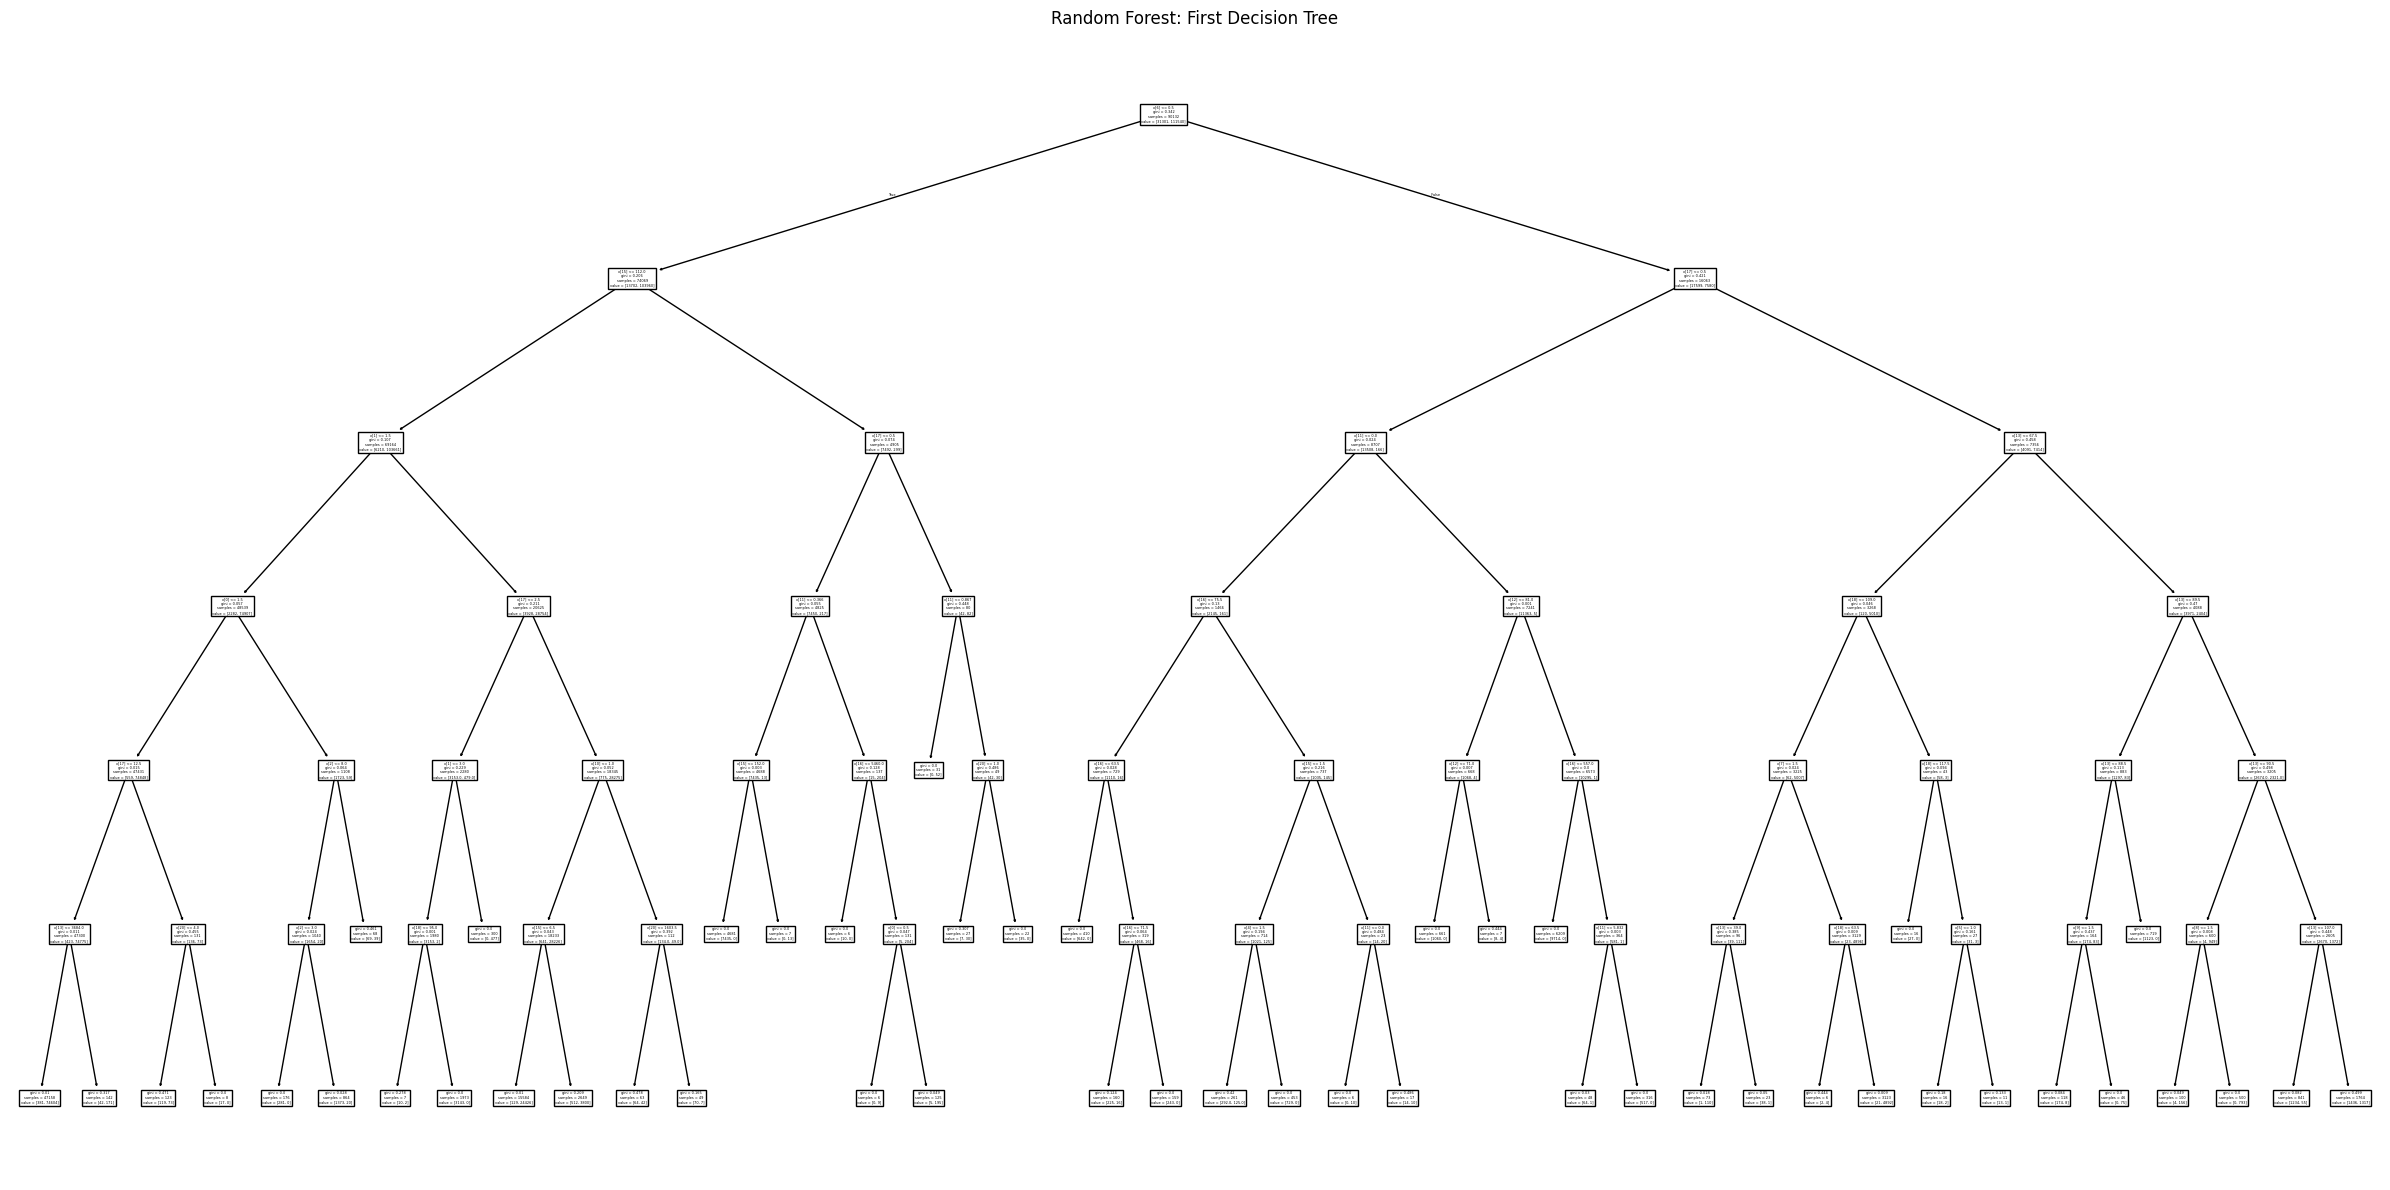

In [94]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

forest = rf_model.named_steps["model"]
tree = forest.estimators_[0]

# ColumnTransformer outputs categorical columns first, then numeric columns
feature_names = categorical_cols + numeric_cols
class_names = [str(label) for label in forest.classes_]

plt.figure(figsize=(24, 12))

plot_tree(
    tree
)

plt.title("Random Forest: First Decision Tree")
plt.tight_layout()
plt.show()

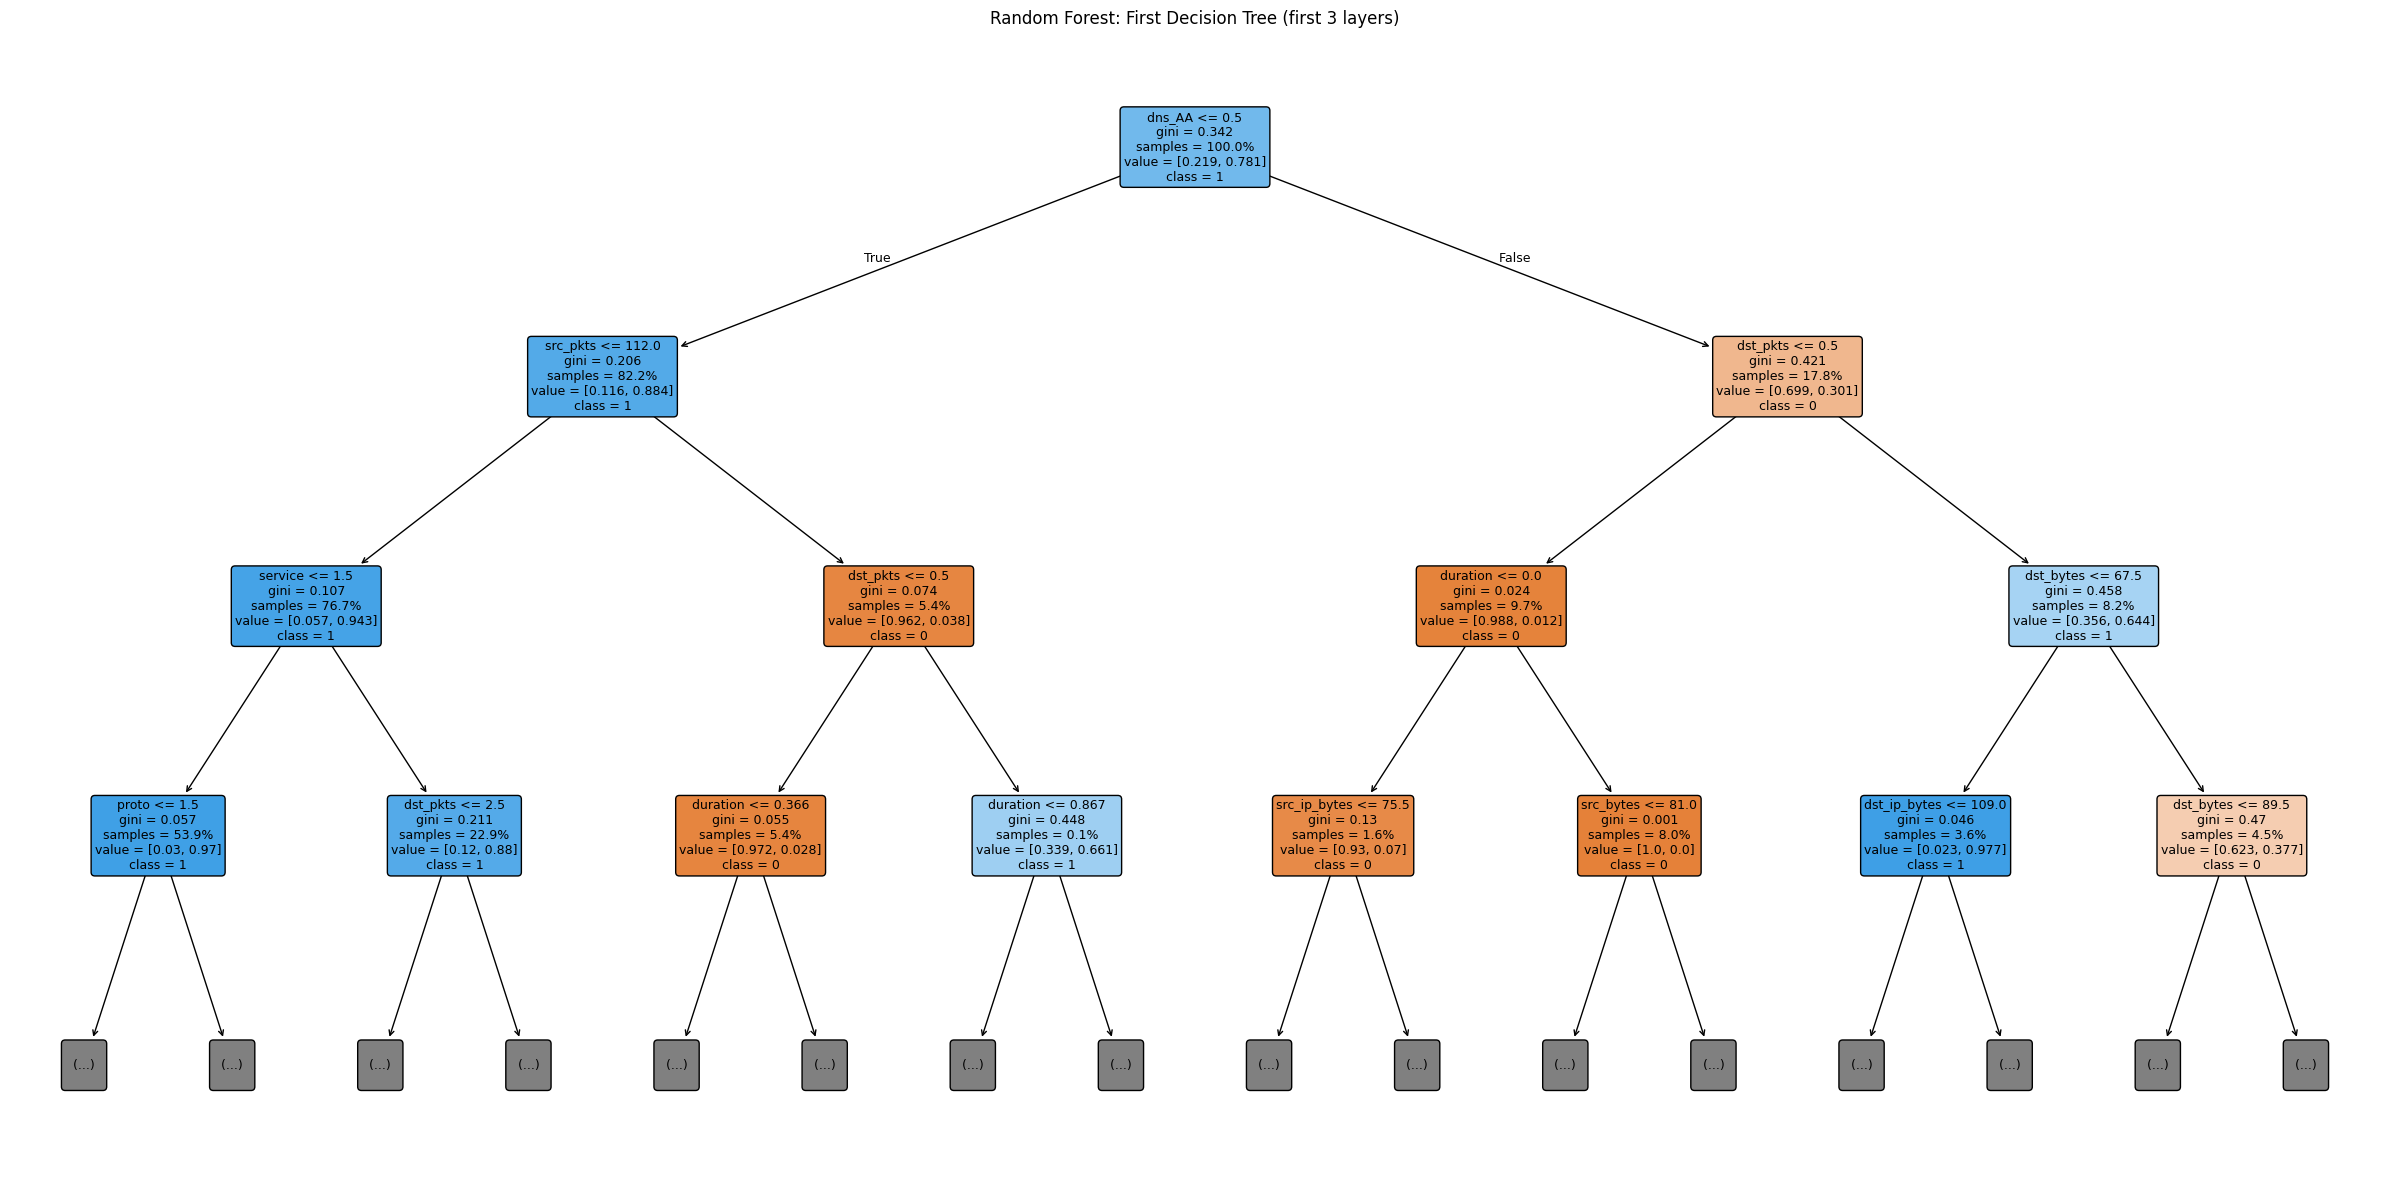

In [95]:
plt.figure(figsize=(24, 12))

plot_tree(
    tree,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
    proportion=True,
    precision=3
)

plt.title("Random Forest: First Decision Tree (first 3 layers)")
plt.tight_layout()
plt.show()

## 5. Evaluate model performance

In [96]:
y_pred = rf_model.predict(X_test)
y_score = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9909    0.9645    0.9775     10505
           1     0.9900    0.9975    0.9937     37109

    accuracy                         0.9902     47614
   macro avg     0.9905    0.9810    0.9856     47614
weighted avg     0.9902    0.9902    0.9902     47614



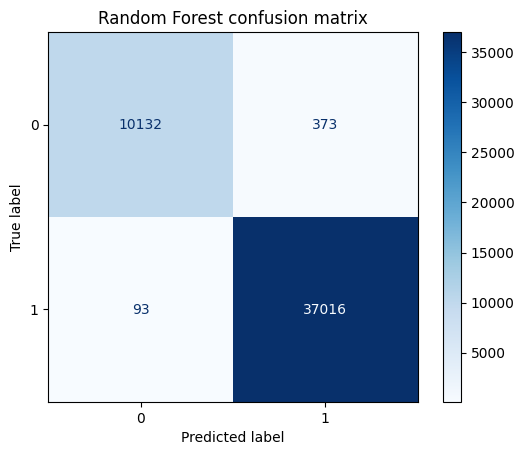

In [97]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    values_format="d",
)
plt.title("Random Forest confusion matrix")
plt.show()

## Separate test: meaningful Random Forest features

This section tests whether the Random Forest depends on meaningful network-behavior features or suspicious identifier-like features. It is intentionally separate from the main training and evaluation code.

In [ ]:
def feature_group(feature):
    behavior_features = {
        "duration", "src_bytes", "dst_bytes", "missed_bytes",
        "src_pkts", "src_ip_bytes", "dst_pkts", "dst_ip_bytes",
        "http_request_body_len", "http_response_body_len",
    }
    protocol_state_features = {
        "proto", "service", "conn_state", "dns_qclass", "dns_qclass_name",
        "dns_qtype", "dns_qtype_name", "dns_rcode", "dns_rcode_name", "dns_AA", "dns_RD",
        "dns_RA", "dns_rejected", "ssl_established", "ssl_resumed",
        "ssl_version", "ssl_cipher",
    }
    content_metadata_features = {
        "http_method", "http_uri", "http_version", "http_user_agent",
        "http_orig_mime_types", "http_resp_mime_types", "http_status_code",
        "http_trans_depth",
    }
    identifier_features = {"src_ip", "dst_ip", "src_port", "dst_port", "dns_query"}

    if feature in behavior_features:
        return "behavior"
    if feature in protocol_state_features:
        return "protocol/state"
    if feature in content_metadata_features:
        return "content/app metadata"
    if feature in identifier_features:
        return "identifier/high-cardinality"
    return "other"


perm_importance = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="f1",
    n_jobs=1,
)

importance_df = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm_importance.importances_mean,
        "importance_std": perm_importance.importances_std,
    })
    .assign(feature_group=lambda df_: df_["feature"].map(feature_group))
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.head(20).round(4))

group_summary = (
    importance_df.groupby("feature_group", as_index=False)["importance_mean"]
    .sum()
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(group_summary.round(4))

### Feature-meaning test result

Local run result: the Random Forest is mainly using `proto`, `src_pkts`, packet/byte counts, `duration`, DNS flags, and HTTP status/body-length fields. That is mostly meaningful because these describe network behavior or protocol/state, not raw identifiers.

| Rank | Feature | Importance mean | Feature group |
|---:|---|---:|---|
| 1 | `proto` | 0.1143 | protocol/state |
| 2 | `src_pkts` | 0.0345 | behavior |
| 3 | `dns_RA` | 0.0023 | protocol/state |
| 4 | `src_ip_bytes` | 0.0017 | behavior |
| 5 | `dst_pkts` | 0.0016 | behavior |
| 6 | `duration` | 0.0004 | behavior |
| 7 | `http_status_code` | 0.0004 | content/app metadata |
| 8 | `http_response_body_len` | 0.0004 | behavior |
| 9 | `dst_bytes` | 0.0003 | behavior |
| 10 | `dns_rejected` | 0.0002 | protocol/state |

Grouped importance from the same run: `protocol/state` = 0.1171, `behavior` = 0.0392, `content/app metadata` = 0.0004, `other` = 0.0002. No raw IP address, port, or DNS query identifier appears in the top features because those high-cardinality columns were removed before training.

The first Random Forest model achieved approximately 99.82% accuracy. Because this result was so high, the riisk of overfitting was investigated.

I found that 55.73% of the final feature rows were duplicates. 13 feature-identical groups also contained conflicting labels (meaning the have the same features but different label). Duplicate records and ambiguous groups were handled before retraining the model.

After cleaning and constraining the trees, the Random Forest still achieved high accuracy, F1, and recall score. 